# Day 1: Economic Dispatch Toy (LP)

**Forecasting is a means, not an end.** Today we build the optimization layer: a linear program that dispatches generators to meet demand at minimum cost.

## LP mental model

- **Objective:** minimize total generation cost
- **Decision variables:** MW output of each generator each hour (continuous, non-negative)
- **Constraints:** power balance (supply = demand), generator capacity limits

Storage arbitrage is a pure LP (charge/discharge rates are continuous). Unit commitment — deciding whether a thermal unit is on or off — requires **binary** variables, making it a MILP.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.dispatch.economic_dispatch import (
    default_demand,
    default_generators,
    marginal_generator_cost,
    solve_economic_dispatch,
    verify_lmps,
)

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

## Build the toy

Three generators in merit order (cheapest dispatched first). Demand is a synthetic 24-hour profile.

,generator,marginal_cost_$MWh,pmax_MW
0,gen0_cheap,20.0,100.0
1,gen1_mid,35.0,80.0
2,gen2_expensive,50.0,50.0


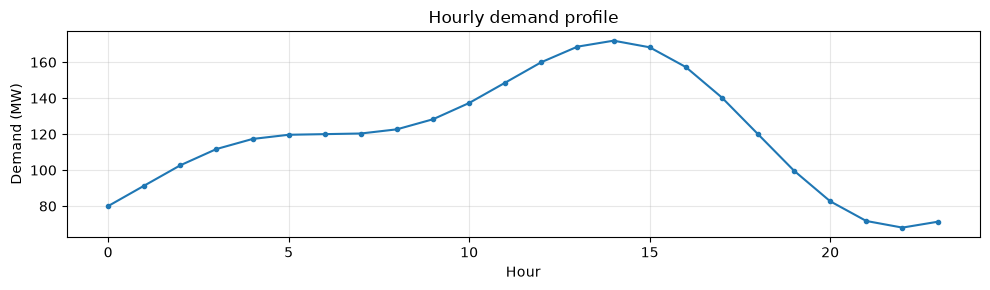

In [2]:
generators = default_generators()
demand = default_demand()

gen_table = pd.DataFrame(
    [{"generator": g.name, "marginal_cost_$MWh": g.marginal_cost, "pmax_MW": g.pmax} for g in generators]
)
display(gen_table)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(demand, marker="o", markersize=3)
ax.set_xlabel("Hour")
ax.set_ylabel("Demand (MW)")
ax.set_title("Hourly demand profile")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Solve and inspect dispatch

Merit-order dispatch: fill cheap generator first, then mid, then expensive.

Status: optimal
Total cost: $66,827.90


generator,gen0_cheap,gen1_mid,gen2_expensive
hour,,,
0,80.000000,7.213429e-09,3.586536e-09
1,91.362967,5.781394e-09,3.245057e-09
2,100.000000,2.679492e+00,7.459231e-09
3,100.000000,1.171573e+01,7.685659e-09
4,100.000000,1.732051e+01,7.696077e-09


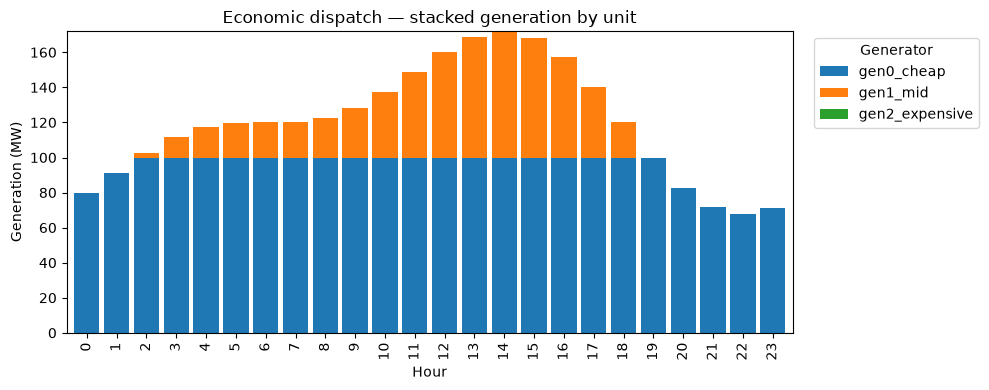

In [3]:
result = solve_economic_dispatch(generators, demand)
print(f"Status: {result.status}")
print(f"Total cost: ${result.total_cost:,.2f}")

wide = result.dispatch_wide()
display(wide.head())

fig, ax = plt.subplots(figsize=(10, 4))
wide.plot(kind="bar", stacked=True, ax=ax, width=0.85)
ax.set_xlabel("Hour")
ax.set_ylabel("Generation (MW)")
ax.set_title("Economic dispatch — stacked generation by unit")
ax.legend(title="Generator", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Duals = LMPs

The dual variable on the power-balance constraint is the **locational marginal price (LMP)** — the shadow price of one additional MW of demand. It equals the marginal cost of the most expensive generator still dispatched.

,lmp,marginal_cost,abs_error,matches
0,20.0,20.0,6.331614e-09,True
1,20.0,20.0,2.014480e-08,True
2,35.0,35.0,4.595332e-08,True
3,35.0,35.0,9.681060e-09,True
4,35.0,35.0,5.435723e-09,True
5,35.0,35.0,4.474067e-09,True
6,35.0,35.0,4.348827e-09,True
7,35.0,35.0,4.227921e-09,True


All 24 hours verified.


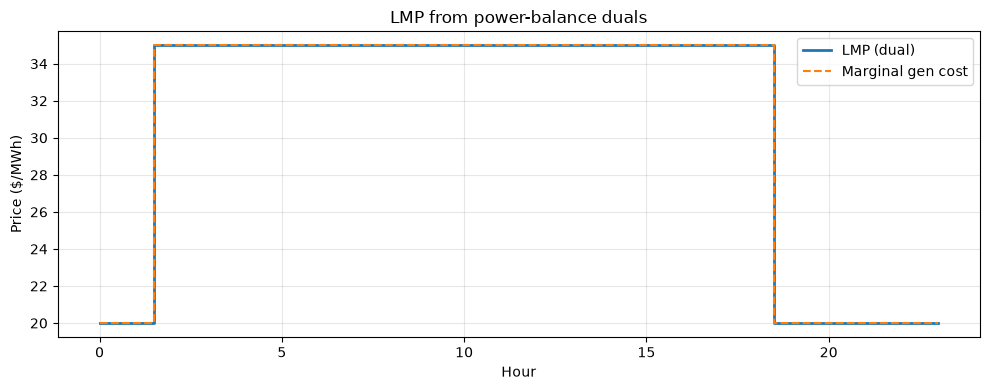

In [4]:
expected_lmp = marginal_generator_cost(result, generators)
verification = verify_lmps(result, generators)
display(verification.head(8))

assert verification["matches"].all(), "LMP duals must match marginal generator cost"
print(f"All {len(verification)} hours verified.")

fig, ax = plt.subplots(figsize=(10, 4))
ax.step(result.lmps.index, result.lmps.values, where="mid", label="LMP (dual)", linewidth=2)
ax.step(expected_lmp.index, expected_lmp.values, where="mid", label="Marginal gen cost", linestyle="--")
ax.set_xlabel("Hour")
ax.set_ylabel("Price ($/MWh)")
ax.set_title("LMP from power-balance duals")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(RESULTS / "economic_dispatch_lmp.png", dpi=150)
plt.show()

## What this means in dispatch / market terms

When demand stays below 100 MW, only the cheap plant (`gen0_cheap` at $20/MWh) runs — the market price is $20. Once demand exceeds 100 MW, the cheap plant is saturated and the next marginal MW comes from `gen1_mid` at $35/MWh — **the LMP jumps to $35**. That price step is the signal storage and flexible load respond to.

This same dual structure appears in AC OPF (pandapower, later this week) where LMPs vary by bus and reflect both marginal generation cost and congestion.